In [1]:
import nibabel as nib
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [54]:
#reshaping the image to 224
#input an image where dimension 1 and 2 are height and width. output the image reshaped to 224x224xN
def reshape(img):

    new_size = 224
    height = img.shape[0]
    width = img.shape[1]
    padding_value = img.min()

    #cropping anything larger than 224
    if height > new_size:
        img = img[(height//2)-(new_size//2):(height//2)+(new_size//2) ,: ,:]

    if width > new_size:
        img = img[:, (width//2)-(new_size//2):(width//2)+(new_size//2) ,:]

    #padding with minimum value if smaller than 224
    if height < new_size:

        pad_top = (new_size//2)-(height//2)
        pad_bottom = (new_size)-(height) - pad_top
        img = np.pad(img, ( (pad_top,pad_bottom), (0,0), (0,0) ), mode='constant', constant_values=padding_value)

    if width < new_size:

        pad_left = (new_size//2)-(width//2)
        pad_right = (new_size)-(width) - pad_left
        img = np.pad(img, ( (0,0), (pad_left,pad_right), (0,0) ), mode='constant', constant_values=padding_value)

    return img

#normalizing
#input an image and output the z-score normalized image
def normalize(img):
    img = (img - img.min()) / (img.max() - img.min())
    return img

#generating the slices and saving them as numpy arrays
#input the file list, the path of original images and the save path
def dataset_generator(files, path, save_path, multilabel=False):
    for nscan, file in enumerate(files):
        img = nib.load(os.path.join(path, file))
        np_img = np.asanyarray(img.dataobj, dtype=np.float32)
        np_img = reshape(np_img)
        if multilabel == True:
            np_img = np_img>0
        else:
            np_img = normalize(np_img)
        #print(np_img.shape)
        for nslice in range(np_img.shape[2]):
            np.save(f"{save_path}image_{nscan+1}_{nslice+1}", np_img[:,:,nslice])
            break

#splitting dataset
def dataset_splitting(files):
    train_val, test_files = train_test_split(files, test_size=0.15, random_state=42)
    train_files, val_files = train_test_split(train_val, test_size=0.15, random_state=42)
    return train_files, val_files, test_files

In [55]:

img_path = "/Users/daniel/Documents/CSAI/Thesis/ThesisCode/data/raw/images/"
label_path = "/Users/daniel/Documents/CSAI/Thesis/ThesisCode/data/raw/labels/"

img_files = os.listdir(img_path)
label_files = os.listdir(label_path)
img_files.sort()
label_files.sort()

#splitting
img_train, img_val, img_test = dataset_splitting(img_files)
label_train, label_val, label_test = dataset_splitting(label_files)

#making datasets
dataset_generator(img_train, img_path, "/Users/daniel/Documents/CSAI/Thesis/ThesisCode/data/slices/images/train/")
dataset_generator(img_val, img_path, "/Users/daniel/Documents/CSAI/Thesis/ThesisCode/data/slices/images/validation/")
dataset_generator(img_test, img_path, "/Users/daniel/Documents/CSAI/Thesis/ThesisCode/data/slices/images/test/")

dataset_generator(label_train, label_path, "/Users/daniel/Documents/CSAI/Thesis/ThesisCode/data/slices/labels/train/", multilabel=True)
dataset_generator(label_val, label_path, "/Users/daniel/Documents/CSAI/Thesis/ThesisCode/data/slices/labels/validation/", multilabel=True)
dataset_generator(label_test, label_path, "/Users/daniel/Documents/CSAI/Thesis/ThesisCode/data/slices/labels/test/", multilabel=True)

(224, 224)
0.58431375
0.054901976


(-0.5, 223.5, 223.5, -0.5)

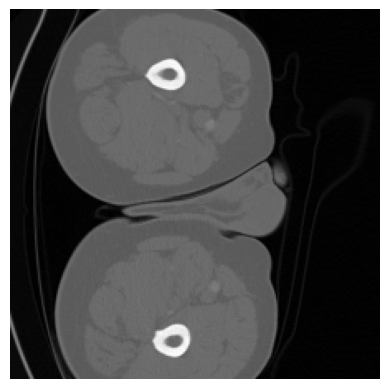

In [57]:
#img = nib.load("/Users/daniel/Documents/CSAI/Thesis/ThesisCode/data/raw/Scan_0011.nii")

np_img = np.load("/Users/daniel/Documents/CSAI/Thesis/ThesisCode/data/slices/images/train/image_1_1.npy")

print(np_img.shape)
print(np_img.max())
print(np_img.min())

plt.figure()
plt.imshow(np_img, cmap='gray')
plt.axis('off')